In [1]:
import pandas as pd
from PIL import Image
import torchvision
from torchvision.models import EfficientNet_B0_Weights
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, auc
from kornia.losses import FocalLoss


# Read the file and load into a DataFrame
ground_truth_df = pd.read_csv('/kaggle/input/ml-exercise-therapanacea/ml_exercise_therapanacea/label_train.txt', header=None, names=['label'])
ground_truth_df.index = ground_truth_df.index + 1
df_hard = pd.read_csv('/kaggle/input/ml-exercise-therapanacea/hard_to_classify_samples.csv', index_col=0)
ground_truth_df = ground_truth_df.join(df_hard, how='outer')

m = torchvision.models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
m.classifier = torch.nn.Linear(in_features=1280, out_features=2, bias=True)
m.to('cuda')
proper_transforms = EfficientNet_B0_Weights.IMAGENET1K_V1.transforms()


class CelebASubsetDataset(Dataset):
    def __init__(self, img_folder, ground_truth_df, indices=None, transform=None, load_weights=True):
        self.img_folder = img_folder
        self.ground_truth_df = ground_truth_df
        self.transform = transform
        if indices is None:
            self.indices = self.ground_truth_df.index.tolist()
        else:
            self.indices = indices
        self.load_weights = load_weights

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx = self.indices[idx]
        img_path = f"{self.img_folder}/{img_idx:06d}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.ground_truth_df.loc[img_idx, 'label']
        if self.load_weights:
            weight = 2.0 if self.ground_truth_df.loc[img_idx, 'hard_to_classify'] else 1.0
            if self.transform:
                transf_image = self.transform(image)
                return transf_image, label, weight
            return image, label, weight
        else:
            if self.transform:
                transf_image = self.transform(image)
                return transf_image, label
            return image, label



def compute_hter(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    far = fp / (fp + tn + 1e-8)  # False Acceptance Rate
    frr = fn / (fn + tp + 1e-8)  # False Rejection Rate
    hter = 0.5 * (far + frr)
    return hter


def find_best_threshold_hter(y_true, y_pred_probs, plot=True):
    """
    Finds the threshold minimizing Half Total Error Rate (HTER).

    Args:
        y_true: True binary labels (0 or 1)
        y_pred_probs: Predicted probabilities
        plot: Whether to plot threshold vs. HTER

    Returns:
        best_threshold: Threshold that minimizes HTER
        best_hter: Corresponding HTER value
    """
    thresholds = np.linspace(0.01, 0.99, 100)
    hter_scores = []

    for t in thresholds:
        y_pred = (y_pred_probs >= t).astype(int)
        hter = compute_hter(y_true, y_pred)
        hter_scores.append(hter)

    best_idx = np.argmin(hter_scores)
    best_threshold = thresholds[best_idx]
    best_hter = hter_scores[best_idx]

    if plot:
        plt.plot(thresholds, hter_scores, label="HTER")
        plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
        plt.xlabel("Threshold")
        plt.ylabel("HTER")
        plt.title("HTER vs Threshold")
        plt.legend()
        plt.grid(True)
        plt.show()

    return best_threshold, best_hter




In [2]:
training_ds = CelebASubsetDataset(
img_folder='/kaggle/input/ml-exercise-therapanacea/ml_exercise_therapanacea/train_img',
ground_truth_df=ground_truth_df,
indices=list(range(1, 80000)), 
transform=proper_transforms
)

validation_ds = CelebASubsetDataset(
img_folder='/kaggle/input/ml-exercise-therapanacea/ml_exercise_therapanacea/train_img',
ground_truth_df=ground_truth_df,
indices=list(range(80001, 100000)),
transform=proper_transforms,
load_weights=False
)

# best Hyperparameters found
num_epochs = 4
focal_gamma = 6
focal_alpha = 0.1
batch_size = 64
learning_rate = 1e-4

# DataLoader
train_loader = DataLoader(training_ds, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_ds, batch_size=batch_size, shuffle=False)

# Loss and optimizer
criterion = FocalLoss(gamma=focal_gamma, alpha=focal_alpha, reduction='none')
optimizer = optim.Adam(m.parameters(), lr=learning_rate)

In [3]:
import torch.nn.functional as F

# Training loop
for epoch in range(num_epochs):
    m.train()
    for i, (transf_images, labels, weights) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        transf_images, labels, weights = transf_images.to('cuda'), labels.to('cuda'), weights.to('cuda')
        optimizer.zero_grad()
        outputs = m(transf_images)
        
        ######################
        """
        loss = sigmoid_focal_loss(inputs=outputs.float(), targets=F.one_hot(labels, num_classes=2).float(), gamma=focal_gamma, alpha=focal_alpha)
        weighted_loss = (loss * weights.unsqueeze(1)).mean()        
        weighted_loss.backward()
        optimizer.step()
        """

        #################################
        loss = criterion(outputs, labels)
        weighted_loss = (loss * weights.unsqueeze(1)).mean()
        weighted_loss.backward()
        optimizer.step()


Epoch 4/4: 100%|██████████| 1250/1250 [06:40<00:00,  3.12it/s]


In [4]:
# VALIDATION ONCE
m.eval()
val_loss = 0.0
all_labels = []
all_preds = []
all_probs = []
with torch.no_grad():
    for val_images, val_labels in tqdm(validation_loader, desc="Validation"):
        val_images, val_labels = val_images.to('cuda'), val_labels.to('cuda')
        val_outputs = m(val_images)
        probs = torch.softmax(val_outputs, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
        all_labels.extend(val_labels.cpu().numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)
val_epoch_loss = val_loss / len(all_labels)

# F1-score
val_f1 = f1_score(all_labels, all_preds)
# Confusion matrix
val_cm = confusion_matrix(all_labels, all_preds)
# PR-AUC
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
val_pr_auc = auc(recall, precision)
# Accuracy
val_acc = (np.array(all_labels) == np.array(all_preds)).mean()

# HTER (Half Total Error Rate)
# For binary classification, confusion_matrix returns [[TN, FP], [FN, TP]]
tn, fp, fn, tp = val_cm.ravel()
far = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Acceptance Rate
frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Rejection Rate
hter = 0.5 * (far + frr)

print(f"Epoch {epoch+1}/{num_epochs}")
print(f"Val F1: {val_f1:.4f}, Val PR-AUC: {val_pr_auc:.4f}, Val Acc: {val_acc:.4f}, HTER: {hter:.4f}")
print("Confusion Matrix:\n", val_cm)

Validation: 100%|██████████| 313/313 [01:39<00:00,  3.13it/s]


Epoch 4/4
Val F1: 0.9440, Val PR-AUC: 0.9956, Val Acc: 0.9059, HTER: 0.0897
Confusion Matrix:
 [[ 2258   207]
 [ 1674 15860]]


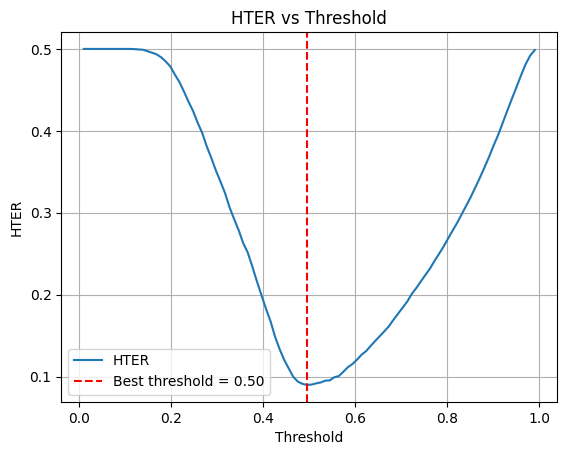

(0.495050505050505, 0.08982264767058337)

In [ ]:
find_best_threshold_hter(np.array(all_labels), np.array(all_probs), plot=True)

In [ ]:
"""
train(
    batch_size=64,
    learning_rate=1e-3,
    focal_alpha=0.25,
    focal_gamma=2.0
)
Val F1: 0.9513, Val PR-AUC: 0.9931, Val Acc: 0.9164, HTER: 0.1198
Confusion Matrix:
 [[ 502  101]
 [ 317 4079]]
========================================================================
train(
    batch_size=64,
    learning_rate=1e-3,
    focal_alpha=0.125,
    focal_gamma=4.0
)

Val F1: 0.9270, Val PR-AUC: 0.9932, Val Acc: 0.8788, HTER: 0.1097
Confusion Matrix:
 [[ 546   57]
 [ 549 3847]]
-----PUIS RE-RUN:--------
Val F1: 0.9407, Val PR-AUC: 0.9920, Val Acc: 0.8996, HTER: 0.1201
Confusion Matrix:
 [[ 515   88]
 [ 414 3982]]

===============================
 train(
    batch_size=64,
    learning_rate=1e-3,
    focal_alpha=0.5,
    focal_gamma=2.0
)
Val F1: 0.9660, Val PR-AUC: 0.9946, Val Acc: 0.9390, HTER: 0.2107
Confusion Matrix:
 [[ 357  246]
 [  59 4337]]
==========================
extreme focal
train(
    batch_size=64,
    learning_rate=1e-3,
    focal_alpha=0.1,
    focal_gamma=10
)

Val F1: 0.9434, Val PR-AUC: 0.9948, Val Acc: 0.9046, HTER: 0.0936
Confusion Matrix:
 [[ 548   55]
 [ 422 3974]]

 =====================
 even more extreme focal
 train(
    batch_size=64,
    learning_rate=1e-3,
    focal_alpha=0.05,
    focal_gamma=10
)
Val F1: 0.8404, Val PR-AUC: 0.9919, Val Acc: 0.7566, HTER: 0.1570
Confusion Matrix:
 [[ 577   26]
 [1191 3205]]
 ==============================
 lower lr w/ extreme focal
 train(
    batch_size=64,
    learning_rate=1e-4,
    focal_alpha=0.1,
    focal_gamma=10
)
Val F1: 0.9256, Val PR-AUC: 0.9947, Val Acc: 0.8770, HTER: 0.1000
Confusion Matrix:
 [[ 561   42]
 [ 573 3823]]
======================
full ds 80k/20k

train(
    batch_size=64,
    learning_rate=1e-4,
    focal_alpha=0.1,
    focal_gamma=6
)

Val F1: 0.9013, Val PR-AUC: 0.9942, Val Acc: 0.8413, HTER: 0.1135
Confusion Matrix:
 [[ 2333   132]
 [ 3042 14492]]
ep2
Val F1: 0.9368, Val PR-AUC: 0.9954, Val Acc: 0.8948, HTER: 0.0868
Confusion Matrix:
 [[ 2311   154]
 [ 1949 15585]]

ep3
 Val F1: 0.9391, Val PR-AUC: 0.9962, Val Acc: 0.8986, HTER: 0.0800
Confusion Matrix:
 [[ 2338   127]
 [ 1901 15633]]

ep4 (BEST) 
 
"""
print("ok")

ok
